In [55]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install shap
!pip install networkx

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.neighbors import kneighbors_graph

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

import shap
import networkx as nx

In [57]:
df = pd.read_csv("microbiome.csv")

print(df.shape)
df.head()

(3387, 571)


,External ID,Participant ID,week_num,diagnosis,fecalcal,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,...,Prevotella histicola,Prevotella pallens,Chlamydia ibidis,Enterococcus mundtii,Anaerostipes sp 992a,Actinobaculum sp oral taxon 183,Lachnoclostridium sp An298,Haemophilus haemolyticus,Enterococcus dispar,Atopobium minutum
0,CSM5FZ3N,C3001,0.0,Crohns Disease,193.89000,42.34520,31.29744,6.81155,5.29200,5.01599,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CSM5FZ4C,C3001,8.0,Crohns Disease,61.34000,12.29822,28.74672,26.46909,2.74544,2.73659,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CSM5MCVV,C3001,16.0,Crohns Disease,115.27000,12.38214,15.91063,3.77383,0.25195,0.24233,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CSM67UA2,C3001,28.0,Crohns Disease,23.20350,36.69818,28.04901,16.81345,1.25428,1.94912,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CSM79HGP,C3001,38.0,Crohns Disease,37.17836,33.26674,36.24943,7.88757,1.20698,1.48374,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
df['diagnosis'] = df['diagnosis'].astype(str)

df['diagnosis'] = df['diagnosis'].str.strip()

df['diagnosis'] = df['diagnosis'].str.lower()

In [59]:
df = df[
    df['diagnosis'].str.contains('crohn') |
    df['diagnosis'].str.contains('ulcer')
]

print("Filtered Shape:", df.shape)

Filtered Shape: (2521, 571)


In [60]:
def encode_label(x):

    if 'crohn' in x:
        return 1

    elif 'ulcer' in x:
        return 0

df['diagnosis'] = df['diagnosis'].apply(encode_label)

print(df['diagnosis'].value_counts())

diagnosis
1    1608
0     913
Name: count, dtype: int64


In [61]:
drop_cols = [
    'External ID',
    'Participant ID',
    'week_num',
    'diagnosis'
]

existing_cols = [
    c for c in drop_cols
    if c in df.columns
]

X = df.drop(columns=existing_cols)

y = df['diagnosis']

In [62]:
imputer = SimpleImputer(strategy='mean')

X_imputed = imputer.fit_transform(X)

In [63]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

In [64]:
pca = PCA(n_components=min(50, X_scaled.shape[1]))

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (2521, 50)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [66]:
k = 5

A_train = kneighbors_graph(
    X_train,
    k,
    mode='connectivity',
    include_self=True
)

A_test = kneighbors_graph(
    X_test,
    k,
    mode='connectivity',
    include_self=True
)

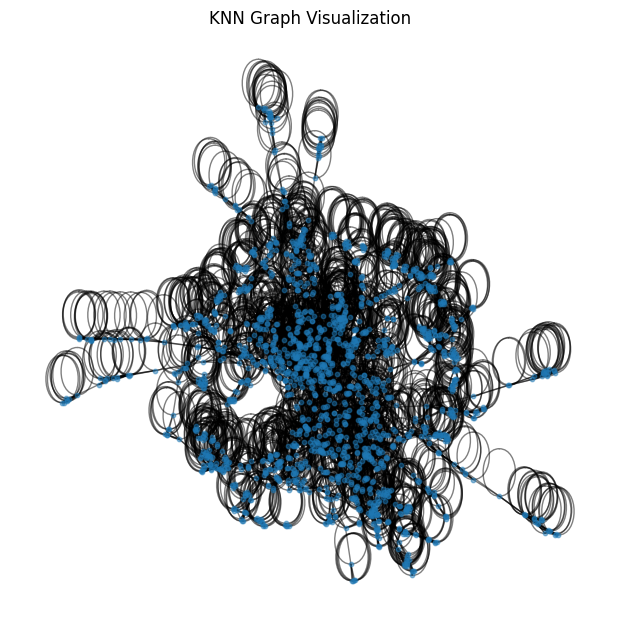

In [67]:
G = nx.from_scipy_sparse_array(A_train)

plt.figure(figsize=(6,6))

nx.draw(
    G,
    node_size=10,
    alpha=0.5
)

plt.title("KNN Graph Visualization")

plt.show()

In [68]:
def convert_to_edge_index(A):

    A = A.tocoo()

    edge_index = np.vstack(
        (A.row, A.col)
    )

    return torch.tensor(
        edge_index,
        dtype=torch.long
    )

edge_train = convert_to_edge_index(A_train)

edge_test = convert_to_edge_index(A_test)

In [69]:
data_train = Data(
    x=torch.tensor(X_train, dtype=torch.float),
    edge_index=edge_train,
    y=torch.tensor(y_train.values, dtype=torch.long)
)

data_test = Data(
    x=torch.tensor(X_test, dtype=torch.float),
    edge_index=edge_test,
    y=torch.tensor(y_test.values, dtype=torch.long)
)

In [70]:
class HybridModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=input_dim,
                nhead=2,
                batch_first=True
            ),
            num_layers=2
        )

        self.gcn1 = GCNConv(input_dim, 64)

        self.gcn2 = GCNConv(64, 2)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = x.unsqueeze(1)

        x = self.transformer(x)

        x = x.squeeze(1)

        x = self.gcn1(x, edge_index)

        x = F.relu(x)

        x = self.gcn2(x, edge_index)

        return x

In [71]:
model = HybridModel(
    input_dim=X_train.shape[1]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)

loss_fn = nn.CrossEntropyLoss()

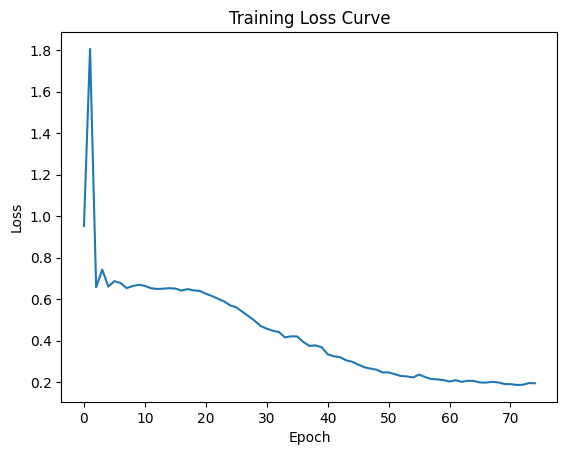

In [72]:
loss_list = []

for epoch in range(75):

    model.train()

    optimizer.zero_grad()

    output = model(data_train)

    loss = loss_fn(
        output,
        data_train.y
    )

    loss.backward()

    optimizer.step()

    loss_list.append(loss.item())

# Loss Graph

plt.plot(loss_list)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [73]:
model.eval()

with torch.no_grad():

    logits = model(data_test)

preds = logits.argmax(dim=1)

In [74]:
acc = accuracy_score(
    data_test.y.cpu(),
    preds.cpu()
)

print("Accuracy =", acc)

Accuracy = 0.8824306472919419


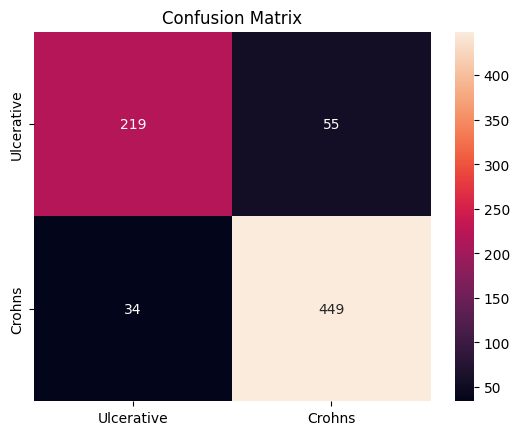

In [75]:
cm = confusion_matrix(
    data_test.y.cpu(),
    preds.cpu()
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ulcerative','Crohns'],
    yticklabels=['Ulcerative','Crohns']
)

plt.title("Confusion Matrix")

plt.show()

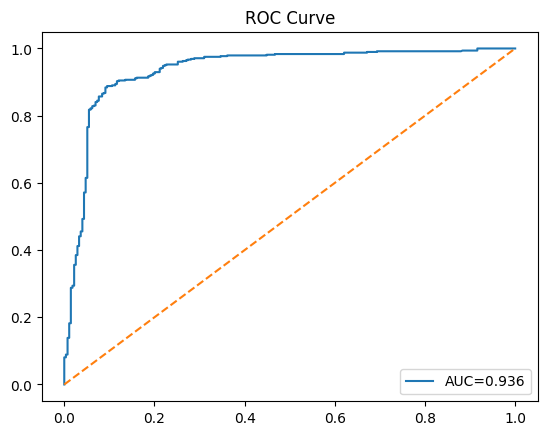

AUC = 0.9362371733841108


In [76]:
probs = F.softmax(
    logits,
    dim=1
)[:,1]

fpr, tpr, _ = roc_curve(
    data_test.y.cpu(),
    probs.cpu()
)

roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC =", roc_auc)

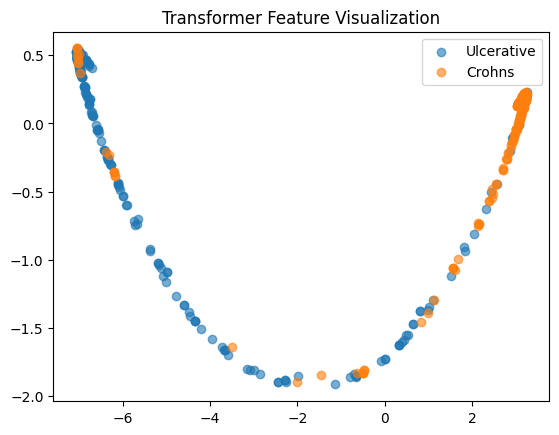

In [77]:
with torch.no_grad():

    x = data_test.x

    transformer_features = model.transformer(
        x.unsqueeze(1)
    ).squeeze(1)

features_np = transformer_features.cpu().numpy()

labels_np = data_test.y.cpu().numpy()

pca_vis = PCA(n_components=2)

features_2d = pca_vis.fit_transform(features_np)

plt.scatter(
    features_2d[labels_np==0,0],
    features_2d[labels_np==0,1],
    label="Ulcerative",
    alpha=0.6
)

plt.scatter(
    features_2d[labels_np==1,0],
    features_2d[labels_np==1,1],
    label="Crohns",
    alpha=0.6
)

plt.legend()

plt.title("Transformer Feature Visualization")

plt.show()

PermutationExplainer explainer: 101it [02:36,  1.66s/it]
/tmp/ipykernel_5905/347904396.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


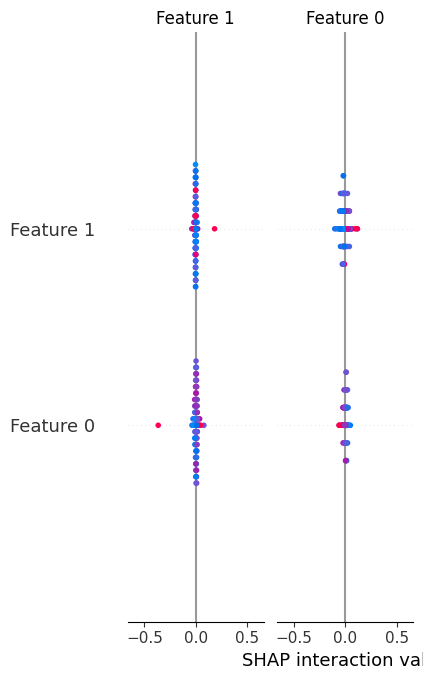

/tmp/ipykernel_5905/347904396.py:59: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


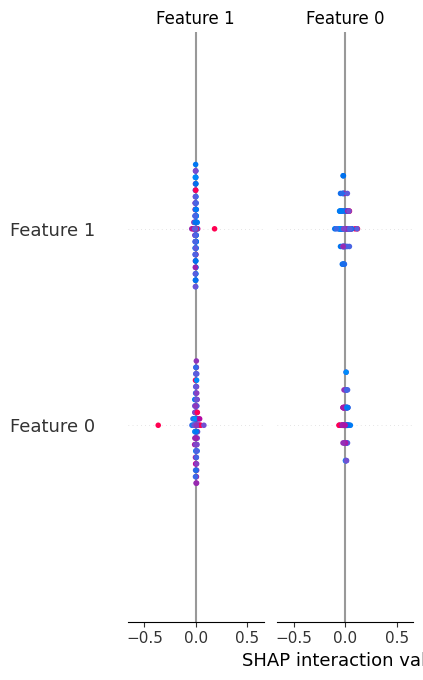

In [78]:


import shap
import numpy as np

# Use small sample (important for speed)

sample_size = min(100, data_test.x.shape[0])

X_sample = data_test.x[:sample_size]

# Create prediction wrapper

def model_predict(x):

    x_tensor = torch.tensor(
        x,
        dtype=torch.float
    )

    temp_data = Data(
        x=x_tensor,
        edge_index=data_test.edge_index
    )

    model.eval()

    with torch.no_grad():

        logits = model(temp_data)

        probs = F.softmax(
            logits,
            dim=1
        )

    return probs.numpy()

# Create explainer

explainer = shap.Explainer(
    model_predict,
    X_sample.numpy()
)

# Compute SHAP values

shap_values = explainer(
    X_sample.numpy()
)

# Plot summary

shap.summary_plot(
    shap_values,
    X_sample.numpy()
)

# Bar Plot (Top Features)

shap.summary_plot(
    shap_values,
    X_sample.numpy(),
    plot_type="bar"
)